In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [3]:
def compute_loss(y,hx):
    return -np.mean(y*np.log(hx) + (1-y)*np.log(1-hx))

In [4]:
def compute_gradient(X,y,hx):
    return np.dot(X.T,hx-y)/y.shape[0]

In [5]:
X = np.array([
    [2,1],
    [3,2],
    [4,4],
    [1,5],
    [2,6],
    [3,7]])
y = np.array([1,1,1,0,0,0])

In [6]:
X.T

array([[2, 3, 4, 1, 2, 3],
       [1, 2, 4, 5, 6, 7]])

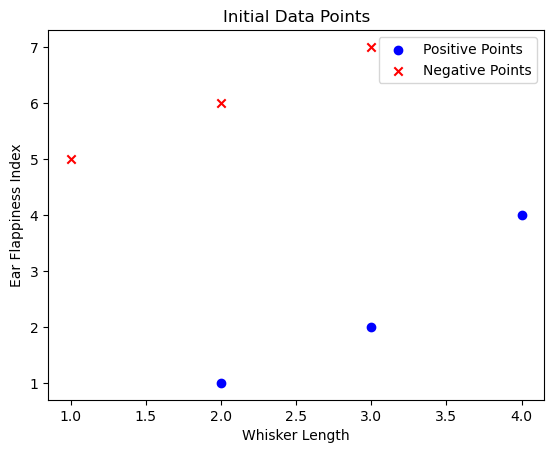

In [7]:
# Plot the initial points
plt.scatter(X[:3,0],X[:3,1],c = 'blue',marker='o',label = 'Positive Points')
plt.scatter(X[3:,0],X[3:,1],c = 'red',marker='x',label = 'Negative Points')
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.title('Initial Data Points')
plt.legend()
plt.show()

In [8]:
def plot_decision_boundary(X,y,weights,loss,iteration):
    plt.scatter(X[:3,1],X[:3,2],c = 'blue',marker='o',label = 'Positive Points' if iteration == 0 else  "" )
    plt.scatter(X[3:,1],X[3:,2],c = 'red',marker='x',label = 'Negative Points' if iteration == 0 else  "" )

    # Extend the x values a bit beyond the mimmum and maximum values for  the data set
    x_values = np.linspace(np.min(X[:,1])-1,np.max(X[:,2])+1,400)
    y_values = -(weights[0] + weights[1]*x_values)/weights[2]
    plt.plot(x_values,y_values,'k')

    # plt.xlim(x_values[0],x_values[-1])
    # plt.ylim(y_values[0],y_values[-1])
    plt.xlabel('Whisker Length')
    plt.ylabel('Ear Flappiness Index')
    plt.title(f"Decision Boundary at iteration {iteration}\n loss {loss}")
    plt.legend()
    plt.show()

In [9]:
#LOgistice Regression Algorithm
def logistic_regression(X,y,Learning_rate = 0.1,num_iterations = 10):
    # Add itercept term to x
    X = np.hstack((np.ones((X.shape[0],1)),X))
    #np.ones takes input in form of tumples

    # Initialize Weights
    weights = np.zeros(X.shape[1])

    # Gradint Decent
    for i in range(num_iterations):
        z = np.dot(X,weights)
        hx = sigmoid(z)
        loss = compute_loss(y,hx)
        gradient = compute_gradient(X,y,hx)
        weights -= Learning_rate*gradient
        plot_decision_boundary(X,y,weights,loss,i)

    return weights

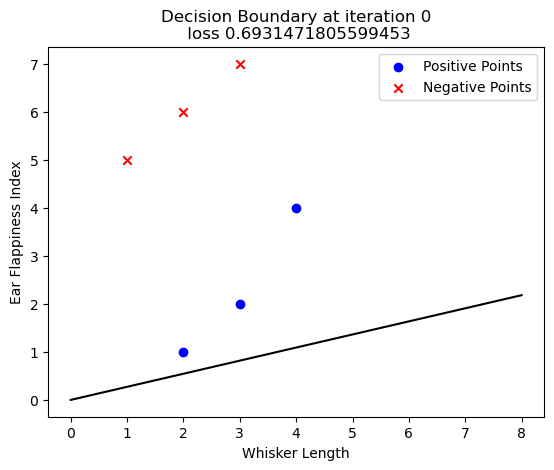

/var/folders/rz/h60gmgln7qvgnmg0h1bwvk180000gn/T/ipykernel_8651/1190504812.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


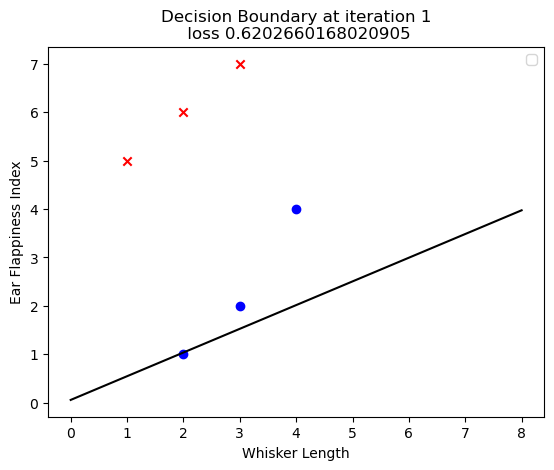

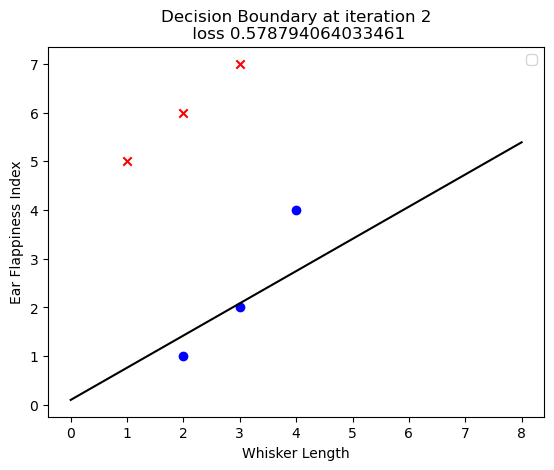

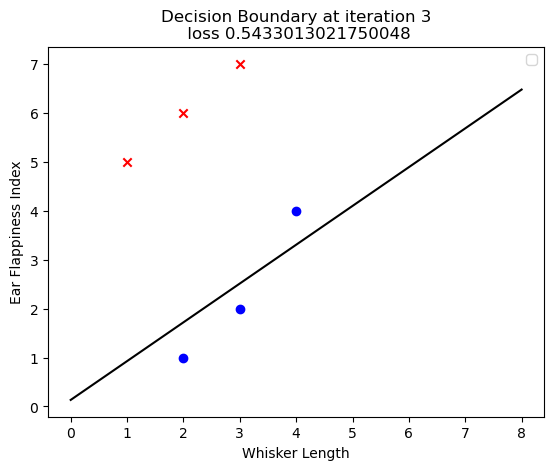

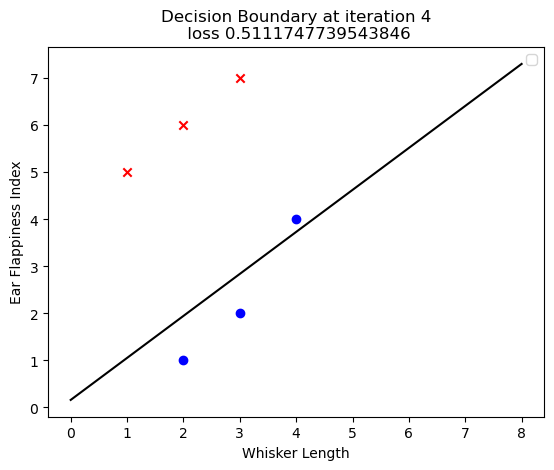

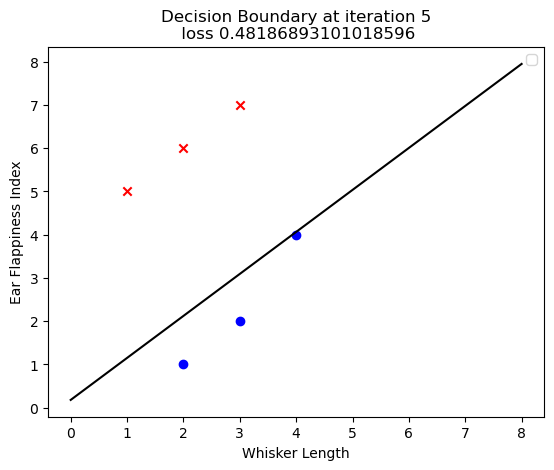

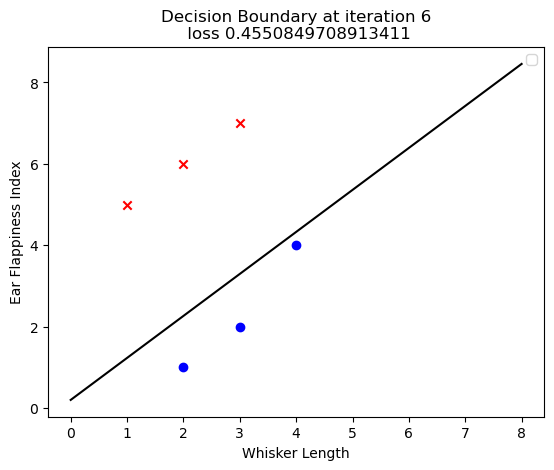

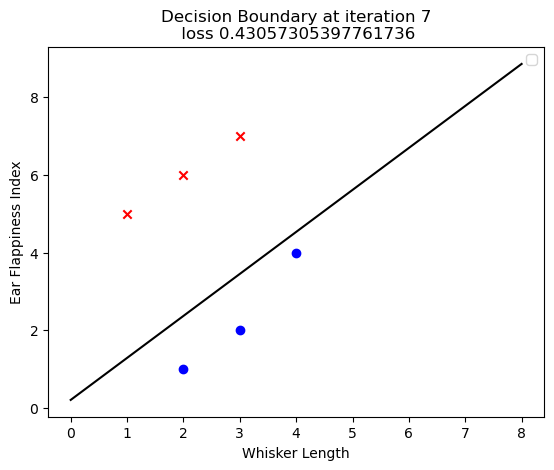

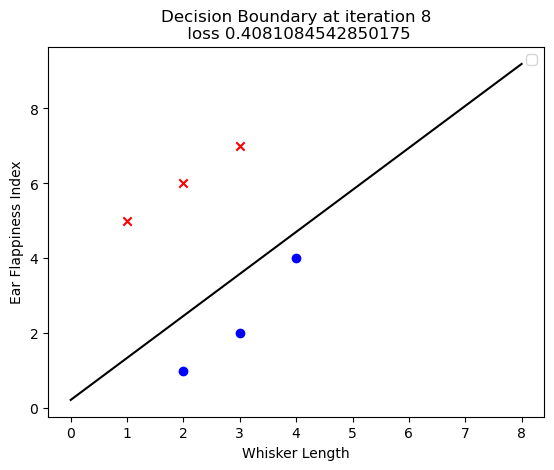

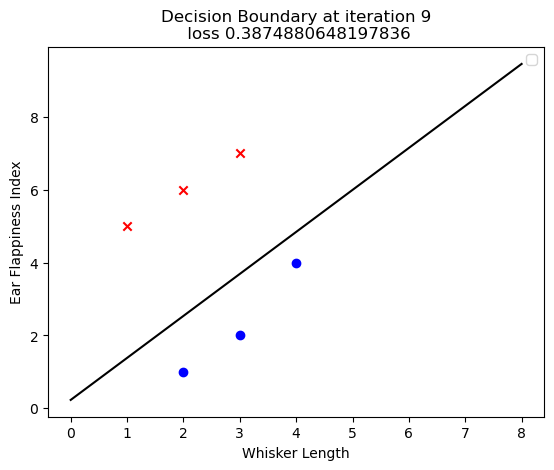

array([ 0.08197221,  0.41197135, -0.35704216])

In [10]:
logistic_regression(X,y)
    